# WTI Crude Oil — Exploratory Analysis & Linear Regression

This notebook walks through downloading WTI and Brent crude oil price data,
visualising it, computing moving averages, and building a simple linear regression
model using CPI and the S&P 500 as predictors.

**Data sources:**
- [Yahoo Finance](https://finance.yahoo.com) via `yfinance` — WTI & Brent daily futures
- [FRED (St. Louis Fed)](https://fred.stlouisfed.org) — US CPI and S&P 500 index


## 1. Imports

Standard data science stack. `yfinance` provides free access to Yahoo Finance futures data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

## 2. Download Oil Price Data

We download daily WTI (`CL=F`) and Brent (`BZ=F`) front-month futures prices from Yahoo Finance
back to January 2000. `auto_adjust=True` adjusts for splits and dividends.
We select only the `Close` column and rename for clarity.

In [2]:
df_oil = yf.download(
    tickers=['CL=F', 'BZ=F'],
    start='2000-01-01',
    interval='1d',       # daily data; '1wk' or '1mo' also valid
    auto_adjust=True
)['Close']

df_oil.columns = ['WTI_USD', 'Brent_USD']  # rename columns
df_oil.dropna(inplace=True)                 # remove rows with missing values
display(df_oil.tail())                      # preview the most recent rows

[*********************100%***********************]  2 of 2 completed


,WTI_USD,Brent_USD
Date,,
2026-06-01,94.980003,92.160004
2026-06-02,96.000000,93.760002
2026-06-03,97.809998,96.019997
2026-06-04,95.029999,93.040001
2026-06-05,93.089996,90.540001


## 3. Quick Plot with Pandas

Pandas DataFrames have a built-in `.plot()` method that wraps Matplotlib.
This is the fastest way to get a visual sanity check on the data.

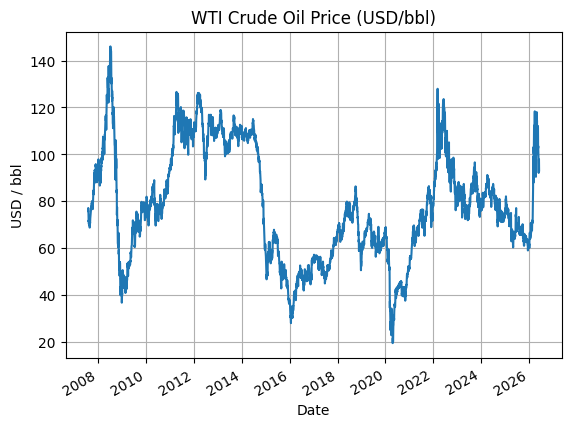

In [3]:
df_oil.WTI_USD.plot(title='WTI Crude Oil Price (USD/bbl)')
plt.grid()
plt.ylabel('USD / bbl')
plt.show()

## 4. Full Series with Matplotlib

Using Matplotlib directly gives finer control over the plot.
Here we plot the entire WTI history from 2000 to present.

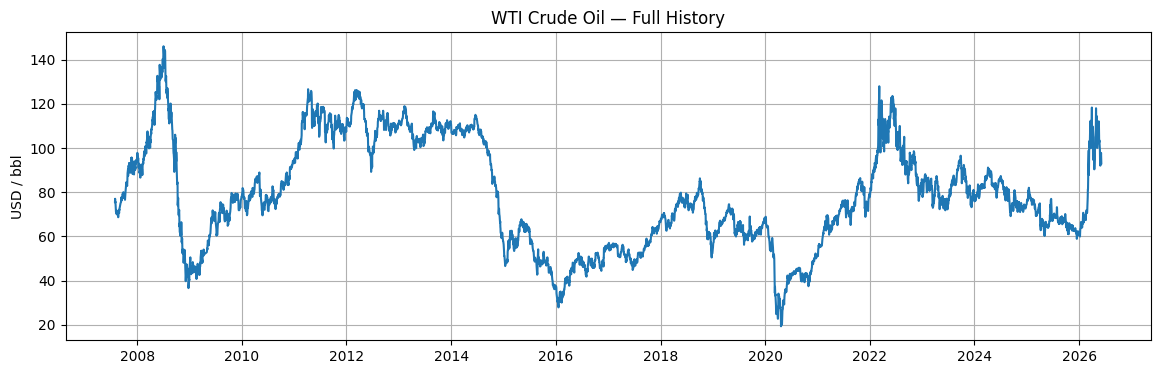

In [4]:
plt.figure(figsize=(14, 4))
plt.plot(df_oil.index, df_oil.WTI_USD)
plt.title('WTI Crude Oil — Full History')
plt.ylabel('USD / bbl')
plt.grid()
plt.show()

## 5. Slicing Recent Data

`df.loc['2026-01-01':]` selects all rows from 1 January 2026 onwards.
This is a standard pandas date-based slice using the `DatetimeIndex`.

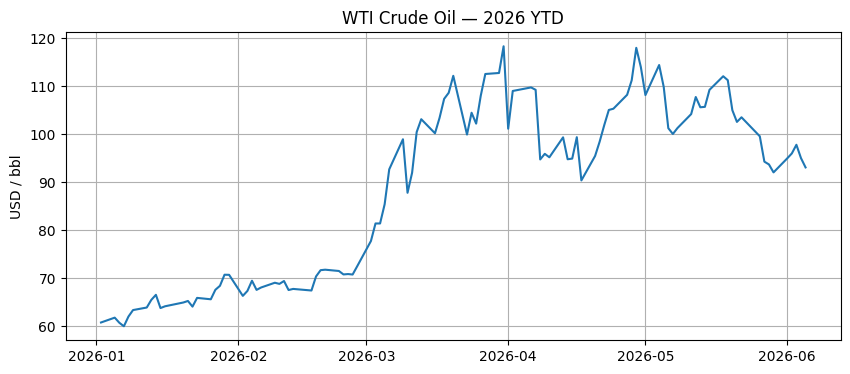

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(df_oil.loc['2026-01-01':].index, df_oil.loc['2026-01-01':, 'WTI_USD'])
plt.title('WTI Crude Oil — 2026 YTD')
plt.ylabel('USD / bbl')
plt.grid()
plt.show()

## 6. Moving Averages

Moving averages smooth out short-term noise and reveal the underlying trend.
We compute four variants on data from 2023 onwards:

| Type | Method | Behaviour |
|---|---|---|
| **SMA 20** | `.rolling(20).mean()` | Equal weight over last 20 days |
| **SMA 50** | `.rolling(50).mean()` | Slower, longer-term trend |
| **EMA 20** | `.ewm(span=20).mean()` | More weight on recent prices — reacts faster |
| **CMA** | `.expanding().mean()` | Cumulative mean from the start of the slice |

A **golden cross** (SMA 20 crossing above SMA 50) is a classic bullish signal used in technical analysis.

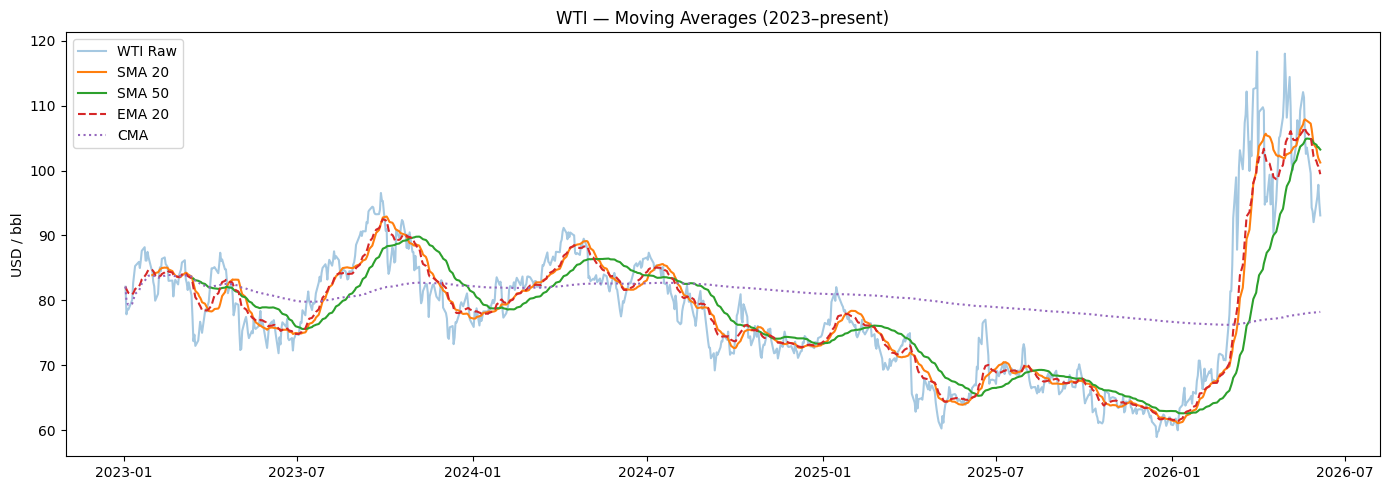

In [6]:
slice = df_oil.loc['2023-01-01':].copy()
slice['SMA_20'] = slice['WTI_USD'].rolling(window=20).mean()
slice['SMA_50'] = slice['WTI_USD'].rolling(window=50).mean()
slice['EMA_20'] = slice['WTI_USD'].ewm(span=20, adjust=False).mean()
slice['CMA']    = slice['WTI_USD'].expanding(min_periods=1).mean()

plt.figure(figsize=(14, 5))
plt.plot(slice.index, slice['WTI_USD'], label='WTI Raw',  alpha=0.4)
plt.plot(slice.index, slice['SMA_20'],  label='SMA 20')
plt.plot(slice.index, slice['SMA_50'],  label='SMA 50')
plt.plot(slice.index, slice['EMA_20'],  label='EMA 20',   linestyle='--')
plt.plot(slice.index, slice['CMA'],     label='CMA',      linestyle=':')
plt.title('WTI — Moving Averages (2023–present)')
plt.ylabel('USD / bbl')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Define Regression Window

We define a date slice of WTI data (2022–2026) that will be merged with
macro indicators downloaded from FRED in the next step.

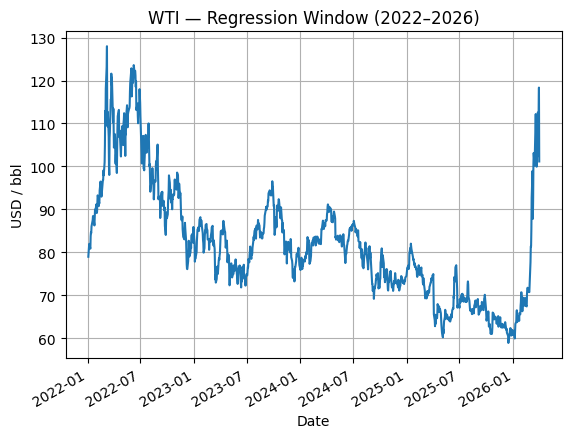

In [7]:
slice = df_oil.loc['2022-01-03':'2026-04-01'].copy()
slice.WTI_USD.plot(title='WTI — Regression Window (2022–2026)')
plt.ylabel('USD / bbl')
plt.grid()
plt.show()

## 8. Download Macro Data from FRED

We download two macro series from the Federal Reserve (FRED) via direct CSV URL —
no API key required:

- **CPI (`CPIAUCSL`)** — US Consumer Price Index, a broad inflation measure
- **S&P 500 (`SP500`)** — US equity benchmark, a proxy for economic sentiment

Both series are resampled to month-start frequency to align with CPI (which is monthly).
Note: this is a demo — the causal link between CPI/S&P 500 and WTI is indirect,
but it illustrates the regression workflow clearly.

In [8]:
def fetch_fred(series_id, start='2022-03-01'):
    url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}'
    df = pd.read_csv(url, index_col='observation_date', parse_dates=True, na_values='.')
    return df[df.index >= start].squeeze()

cpi   = fetch_fred('CPIAUCSL')   # US Consumer Price Index
sp500 = fetch_fred('SP500')       # S&P 500 index

df = pd.concat([cpi, sp500], axis=1)
df.columns = ['CPI', 'SP500']
df = df.resample('MS').last().dropna()   # align to month-start, drop NaN
display(df.head())

/tmp/ipykernel_58333/2936602279.py:9: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat([cpi, sp500], axis=1)


,CPI,SP500
observation_date,,
2022-03-01,287.674,4530.41
2022-04-01,288.561,4131.93
2022-05-01,291.298,4132.15
2022-06-01,294.957,3785.38
2022-07-01,294.913,4130.29


## 9. Merge WTI with Macro Data

We combine WTI (daily) with the monthly macro data using `resample('MS').last()`.
Normalising by the first row (`df / df.iloc[0,:]`) puts all three series on the
same scale (starting at 1.0) so we can visually compare their co-movement.

/tmp/ipykernel_58333/535504035.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat([df, slice['WTI_USD']], axis=1)


,CPI,SP500,WTI_USD
2022-03-01,287.674,4530.41,107.910004
2022-04-01,288.561,4131.93,109.339996
2022-05-01,291.298,4132.15,122.839996
2022-06-01,294.957,3785.38,114.809998
2022-07-01,294.913,4130.29,110.010002


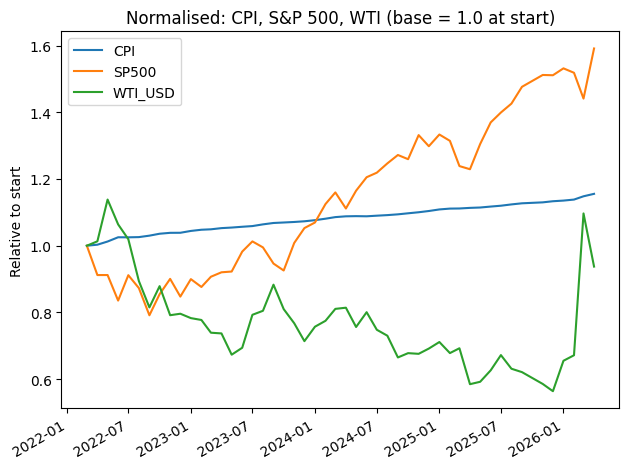

In [9]:
df = pd.concat([df, slice['WTI_USD']], axis=1)
df.columns = ['CPI', 'SP500', 'WTI_USD']
df = df.resample('MS').last().dropna()
display(df.head())

df_norm = df / df.iloc[0, :]   # normalise to base 1.0
df_norm.plot(title='Normalised: CPI, S&P 500, WTI (base = 1.0 at start)')
plt.ylabel('Relative to start')
plt.tight_layout()
plt.show()

## 10. Linear Regression

We fit a simple **Ordinary Least Squares** regression:

$$\text{WTI} = \beta_0 + \beta_1 \cdot \text{CPI} + \beta_2 \cdot \text{SP500} + \epsilon$$

**Train/test split** uses `shuffle=False` — this is essential for time series data.
Shuffling would leak future information into the training set and inflate performance metrics.
We hold out the last 20% of months as the test set.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

features = ['CPI', 'SP500']
X = df[features]
y = df['WTI_USD']

# Time-ordered split — no shuffling for time series
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model  = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"R²  : {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} USD/bbl")
print()
print("Coefficients:")
for feat, coef in zip(features, model.coef_):
    print(f"  {feat:12s}: {coef:.4f}")
print(f"  {'Intercept':12s}: {model.intercept_:.4f}")

R²  : -0.760
RMSE: 23.30 USD/bbl

Coefficients:
  CPI         : -1.6540
  SP500       : 0.0071
  Intercept   : 558.4443


## 11. Actual vs Predicted

The plot below shows the model's predictions (dashed) against actual WTI prices (solid)
on the held-out test set. A good fit would show the dashed line tracking the solid line closely.

Keep in mind this is a **demo** — a linear model with only two features is underpowered
for oil price forecasting. The SARIMA and XGBoost notebooks build on this foundation.

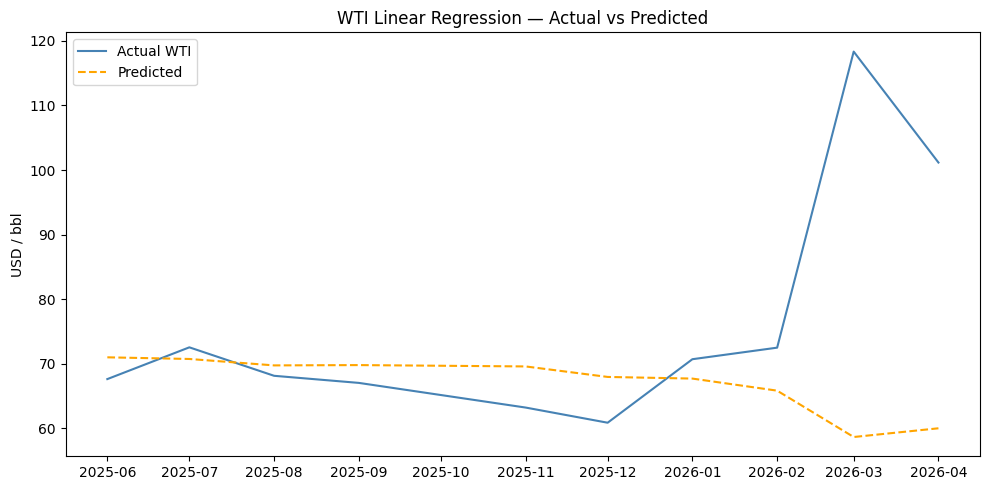

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(y_test.index, y_test.values, label='Actual WTI',   color='steelblue')
ax.plot(y_test.index, y_pred,        label='Predicted',    color='orange', linestyle='--')
ax.set_ylabel('USD / bbl')
ax.set_title('WTI Linear Regression — Actual vs Predicted')
ax.legend()
plt.tight_layout()
plt.show()